In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
test = pd.read_csv('test.csv')
train = pd.read_csv('train.csv')

In [5]:
test.head()

,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,1,1043,1,1.8,1,14,0,5,0.1,193,...,16,226,1412,3476,12,7,2,0,1,0
1,2,841,1,0.5,1,4,1,61,0.8,191,...,12,746,857,3895,6,0,7,1,0,0
2,3,1807,1,2.8,0,1,0,27,0.9,186,...,4,1270,1366,2396,17,10,10,0,1,1
3,4,1546,0,0.5,1,18,1,25,0.5,96,...,20,295,1752,3893,10,0,7,1,1,0
4,5,1434,0,1.4,0,11,1,49,0.5,108,...,18,749,810,1773,15,8,7,1,0,1


In [6]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             1000 non-null   int64  
 1   battery_power  1000 non-null   int64  
 2   blue           1000 non-null   int64  
 3   clock_speed    1000 non-null   float64
 4   dual_sim       1000 non-null   int64  
 5   fc             1000 non-null   int64  
 6   four_g         1000 non-null   int64  
 7   int_memory     1000 non-null   int64  
 8   m_dep          1000 non-null   float64
 9   mobile_wt      1000 non-null   int64  
 10  n_cores        1000 non-null   int64  
 11  pc             1000 non-null   int64  
 12  px_height      1000 non-null   int64  
 13  px_width       1000 non-null   int64  
 14  ram            1000 non-null   int64  
 15  sc_h           1000 non-null   int64  
 16  sc_w           1000 non-null   int64  
 17  talk_time      1000 non-null   int64  
 18  three_g  

In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [8]:
train["price_range"].value_counts()

price_range
1    500
2    500
3    500
0    500
Name: count, dtype: int64

In [9]:
train.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


<Axes: >

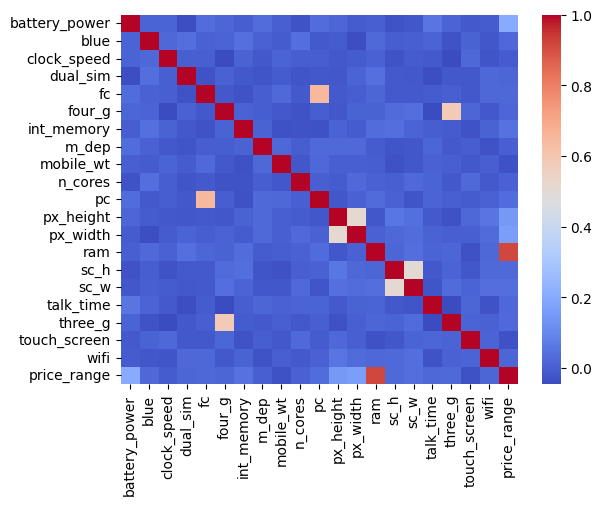

In [10]:
correlation_matrix = train.corr()
sns.heatmap(train.corr(), annot=False, cmap='coolwarm')

# ram ile yüksek ilişkisi var 

In [11]:
target_correlations = correlation_matrix['price_range'].sort_values(ascending=False)

target_correlations

price_range      1.000000
ram              0.917046
battery_power    0.200723
px_width         0.165818
px_height        0.148858
int_memory       0.044435
sc_w             0.038711
pc               0.033599
three_g          0.023611
sc_h             0.022986
fc               0.021998
talk_time        0.021859
blue             0.020573
wifi             0.018785
dual_sim         0.017444
four_g           0.014772
n_cores          0.004399
m_dep            0.000853
clock_speed     -0.006606
mobile_wt       -0.030302
touch_screen    -0.030411
Name: price_range, dtype: float64

In [12]:
X_train = train.drop('price_range', axis=1)
y_train = train['price_range']

In [13]:
X_test = test.drop('id', axis=1) if 'id' in test.columns else test

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# genellikle y normalleştirilmez çünkü hedef değişken ve zaten 0 1 gibi kategorik

In [24]:
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train_scaled, y_train, test_size=0.2, random_state=42
)

In [16]:
# Random Forest Classifier

rf = RandomForestClassifier(random_state=42, n_estimators=300,min_samples_leaf=1,min_samples_split=2,max_depth=20)
rf.fit(X_train_split, y_train_split)
rf_pred = rf.predict(X_val)
rf_accuracy = accuracy_score(y_val, rf_pred)
print('Random Forest Classifier accuracy:', rf_accuracy)

Random Forest Classifier accuracy: 0.8925


Text(0.5, 58.7222222222222, 'Tahmin Edilen Değer')

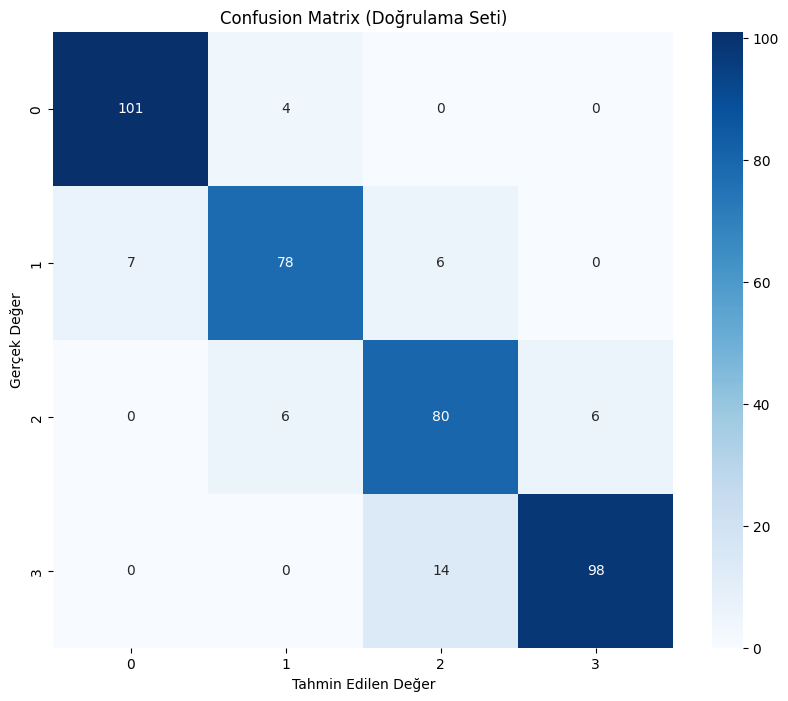

In [26]:
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_val, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Doğrulama Seti)')
plt.ylabel('Gerçek Değer')
plt.xlabel('Tahmin Edilen Değer')

In [17]:
# random forest hipertuning

param_grid = {
    'n_estimators': [100, 200, 300], # 0-50 girseydik model kararsız olabilirdi 1000+ girersek eğitim süresi uzardı ve performansa çok etki etmezdi
    'max_depth': [10, 20, 30], # Düşük değerler (örneğin 5) ağaçları sığ yapar ve öğrenme kapasitesini sınırlar. Yüksek değerler (örneğin 50, 100) aşırı öğrenmeye (overfitting) yol açabilir.
    'min_samples_split': [2, 5, 10], # 2: Ağaç çok fazla bölünür, aşırı öğrenmeye yol açabilir. 10: Daha sağlam ve genelleştirilebilir modeller oluşturur.
    'min_samples_leaf': [1, 2, 4] # Bir yaprak düğümde kalması gereken minimum veri sayısını belirler.

}

rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, n_jobs=-1,scoring='accuracy')
                                                                        # cv = kaç parcaya bölündüğünü belirtir 5 yapsaydık daha güvenli olurdu ama işlem daha uzun sürerdi.
                                                                        # n_jobs = -1 tüm işlemcileri kullanır. 1 yaparsak sadece bir işlemci kullanır.
                                                                        # scoring = hangi metriği kullanacağımızı belirtiriz. accuracy, precision, recall, f1-score gibi
rf_grid.fit(X_train_scaled, y_train)
rf_grid.best_params_


{'max_depth': 20,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 300}

In [18]:
# Gradient Boosting Classifier

gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train_split, y_train_split)
gb_pred = gb.predict(X_val)
gb_accuracy = accuracy_score(y_val, gb_pred)
print('Gradient Boosting Classifier accuracy:', gb_accuracy)

Gradient Boosting Classifier accuracy: 0.905


In [19]:
# Lojisitc Regression Classifier

lr = LogisticRegression(random_state=42)
lr.fit(X_train_split, y_train_split)
lr_pred = lr.predict(X_val)
lr_accuracy = accuracy_score(y_val, lr_pred)
print('Logistic Regression Classifier accuracy:', lr_accuracy)

Logistic Regression Classifier accuracy: 0.9775


Text(0.5, 58.7222222222222, 'Tahmin Edilen Değer')

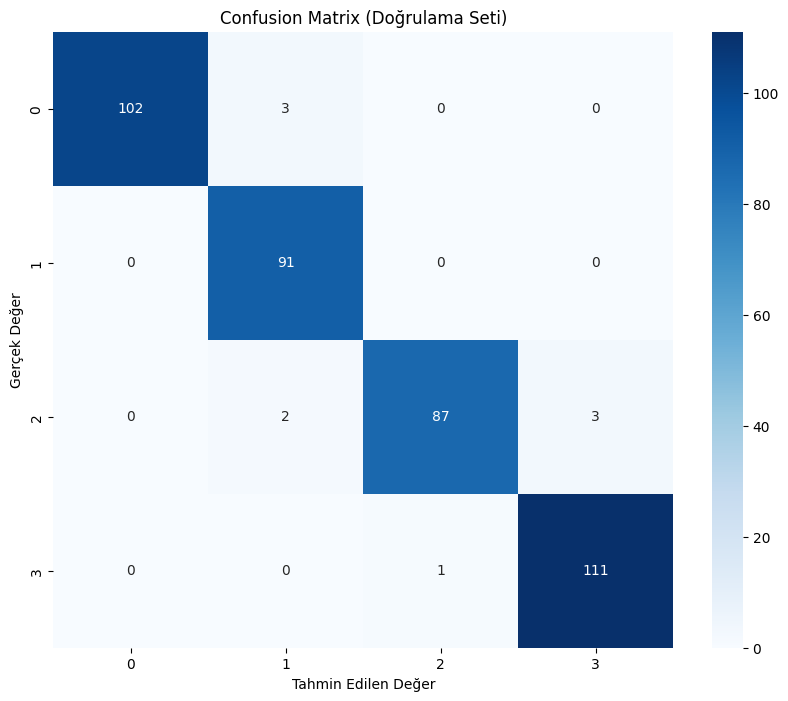

In [36]:
# Logistic Regression grafik    

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_val, lr_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Doğrulama Seti)')  
plt.ylabel('Gerçek Değer')
plt.xlabel('Tahmin Edilen Değer')


In [21]:
# SVM Classifier

svm = SVC(kernel="rbf",random_state=42)
svm.fit(X_train_split, y_train_split)
svm_pred = svm.predict(X_val)
svm_accuracy = accuracy_score(y_val, svm_pred)
print('SVM Classifier accuracy:', svm_accuracy)

SVM Classifier accuracy: 0.8925


In [34]:
def plot_class_separation(X, y, title):
    from sklearn.decomposition import PCA
    
    # PCA ile boyut azaltma
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    
    # Veriyi görselleştirme
    plt.figure(figsize=(12, 10))
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.7, s=50)
    plt.colorbar(scatter, label='Fiyat Aralığı')
    plt.title(f'{title} - PCA ile Sınıf Ayrımı Görselleştirmesi')
    plt.xlabel(f'PC1 (Varyans Oranı: {pca.explained_variance_ratio_[0]:.2f})')
    plt.ylabel(f'PC2 (Varyans Oranı: {pca.explained_variance_ratio_[1]:.2f})')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{title.lower().replace(" ", "_")}_class_separation.png')
    plt.show()
    
    print(f"\nPCA ile toplam açıklanan varyans: {sum(pca.explained_variance_ratio_):.2f}")

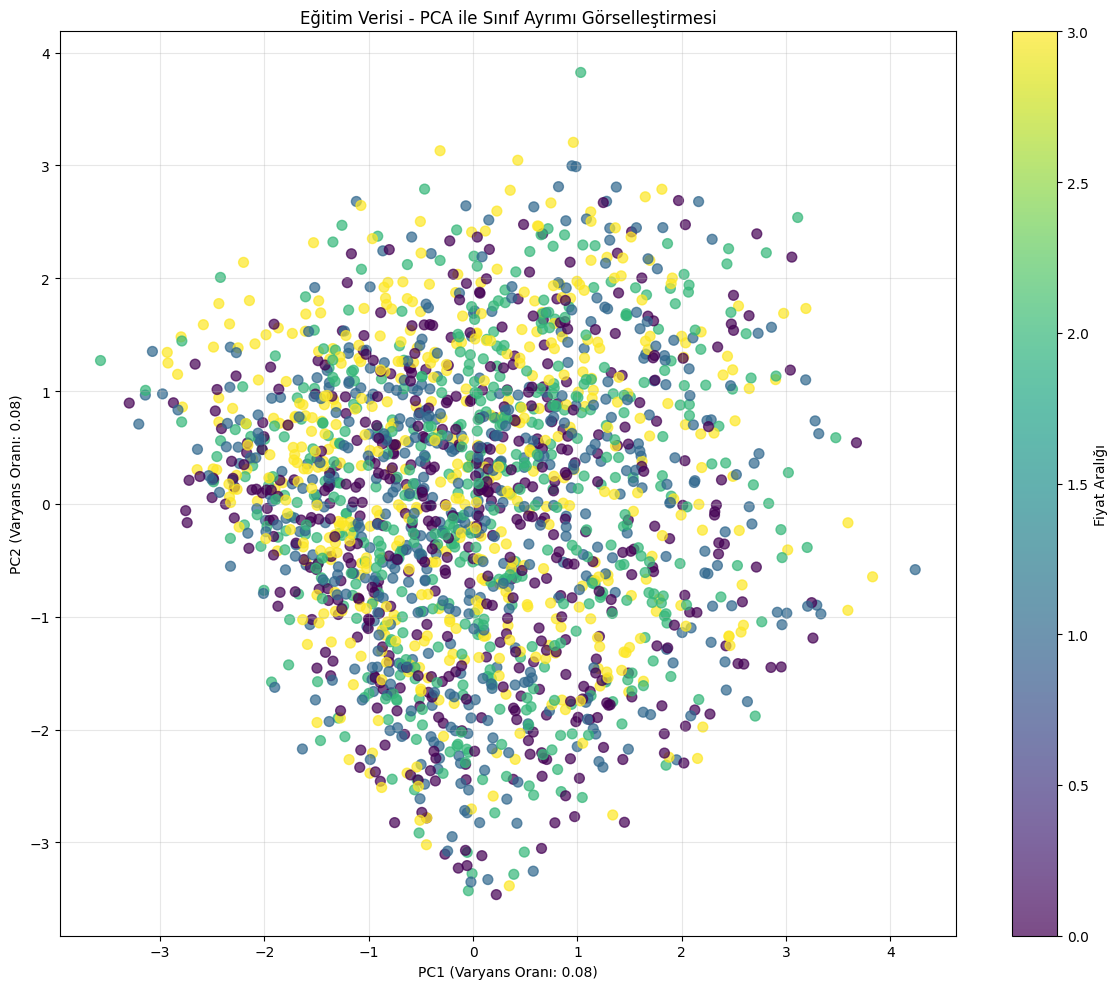


PCA ile toplam açıklanan varyans: 0.16


In [35]:
plot_class_separation(X_train_scaled, y_train, 'Eğitim Verisi')

In [58]:
# best model selection

def bestmodel():
    models = {
        'Random Forest': rf_accuracy,
        'Gradient Boosting': gb_accuracy,
        'Logistic Regression': lr_accuracy,
        'SVM': svm_accuracy
    }

    best_model = max(models, key=models.get)
    return best_model
bestmodel()


'Logistic Regression'

In [54]:
lr_params = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']
}


In [63]:
grid_search_lr = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_grid=lr_params,
    cv=3,
    n_jobs=-1,
    scoring='accuracy'
)
"""
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Model
rf = RandomForestClassifier()

# Parametreler
param_dist = {
    'n_estimators': np.arange(100, 500, 50),
    'max_depth': [10, 20, None],
    'min_samples_split': np.arange(2, 11),
    'min_samples_leaf': np.arange(1, 5)
}

# RandomizedSearchCV
random_search = RandomizedSearchCV(rf, param_distributions=param_dist, n_iter=20, cv=5, n_jobs=-1, verbose=2)
random_search.fit(X_train, y_train)

# En iyi parametreler
print(random_search.best_params_)



"""

grid_search_lr.fit(X_train_scaled, y_train)


GridSearchCV(cv=3, estimator=LogisticRegression(max_iter=1000, random_state=42),
             n_jobs=-1,
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag',
                                    'saga']},
             scoring='accuracy')

In [64]:
best_lr_params = grid_search_lr.best_params_
best_lr_model = grid_search_lr.best_estimator_

In [78]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance':(best_lr_model.coef_[0])
}).sort_values('importance', ascending=False)


# Değişkenlerin Önem Sırası

In [80]:
feature_importance # burada negatif olan ama çok etki eden değerler var.

,feature,importance
8,mobile_wt,2.103908
19,wifi,0.715568
5,four_g,0.204073
18,touch_screen,0.193139
3,dual_sim,0.152496
1,blue,0.150623
2,clock_speed,0.132682
16,talk_time,0.121677
17,three_g,0.115810
7,m_dep,0.075489


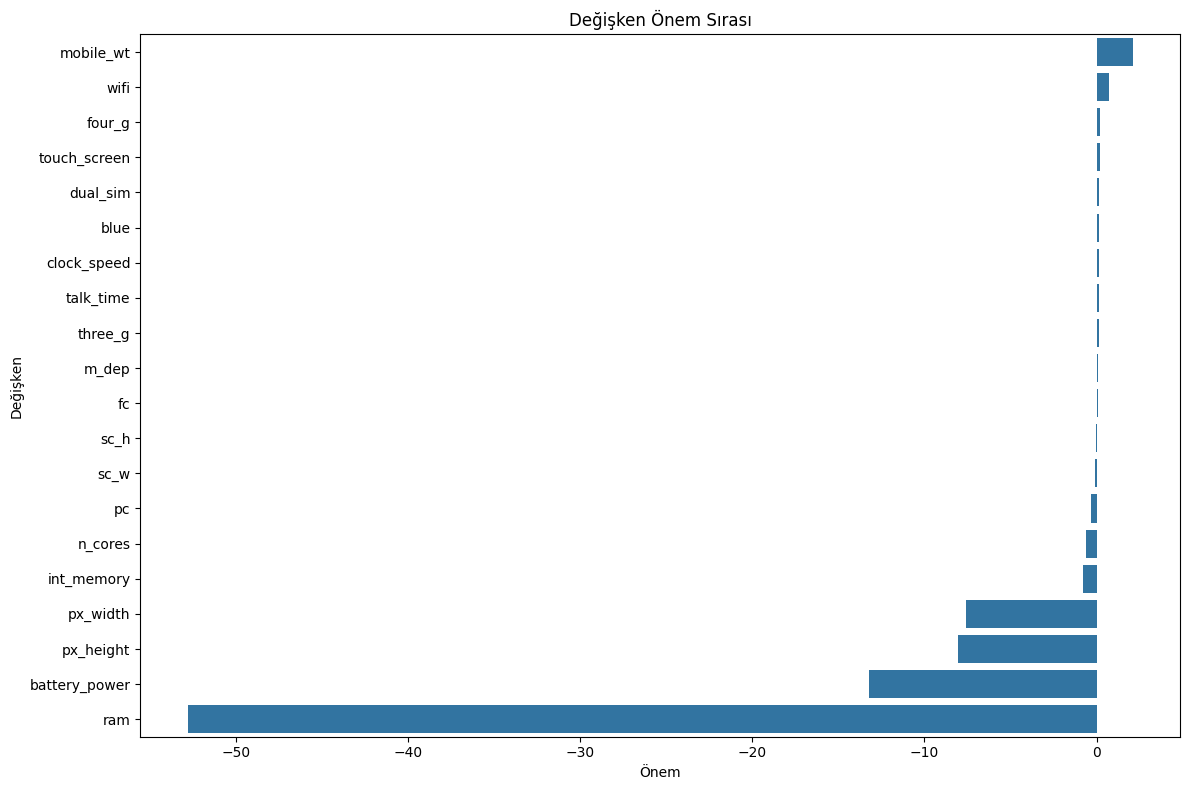

In [69]:
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importance)
plt.title('Değişken Önem Sırası')
plt.xlabel('Önem')
plt.ylabel('Değişken')
plt.tight_layout()


In [83]:
test_predictions = best_lr_model.predict(X_test_scaled)
result_df = pd.DataFrame({
    'id': test['id'],
    'price_range': test_predictions
})

result_df.to_csv('submission.csv', index=False)

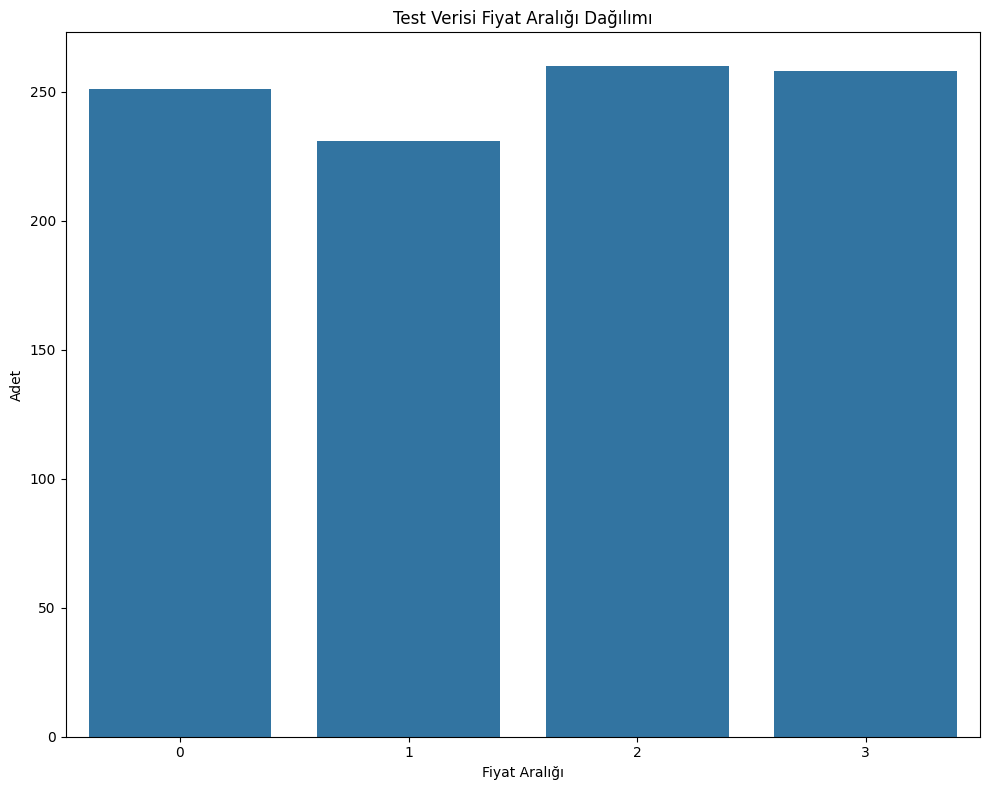

In [87]:
# result_df görselleştirme 

plt.figure(figsize=(10, 8))
sns.countplot(x='price_range', data=result_df)
plt.title('Test Verisi Fiyat Aralığı Dağılımı')
plt.xlabel('Fiyat Aralığı')
plt.ylabel('Adet')
plt.tight_layout()
plt.savefig('test_price_range_distribution.png')
plt.show()

In [86]:
print("\nSınıflandırma Raporu (Doğrulama Seti):")
print(classification_report(y_val, lr_pred))


Sınıflandırma Raporu (Doğrulama Seti):
              precision    recall  f1-score   support

           0       1.00      0.97      0.99       105
           1       0.95      1.00      0.97        91
           2       0.99      0.95      0.97        92
           3       0.97      0.99      0.98       112

    accuracy                           0.98       400
   macro avg       0.98      0.98      0.98       400
weighted avg       0.98      0.98      0.98       400

